<a href="https://colab.research.google.com/github/bpickett14/AdvancedStatisticalMethods/blob/main/Race_Income_Analysis_MultipleLinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
install.packages('Sleuth3')
library('Sleuth3')

head(ex1029)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



,Region,MetropolitanStatus,Exper,Educ,Race,WeeklyEarnings
,<fct>,<fct>,<int>,<int>,<fct>,<dbl>
1,South,NotMetropolitanArea,8,12,NotBlack,859.71
2,Midwest,MetropolitanArea,30,12,NotBlack,786.73
3,West,MetropolitanArea,31,14,NotBlack,1424.50
4,West,MetropolitanArea,17,16,NotBlack,959.16
5,West,MetropolitanArea,6,12,NotBlack,154.32
6,Midwest,MetropolitanArea,24,17,Black,282.19


#Introduction
This analysis uses data from the 1988 March U.S. Current Population Survey, which includes weekly wages in 1987 (in 1992 dollars) for 25,437 full-time employed males ages 18 to 70. The dataset also provides information on years of education, years of work experience, race (Black or non-Black), region of the United States (Northeast, Midwest, South, West), and whether the individual worked in a metropolitan area.

The goal of this study is to examine whether Black males were paid less than non-Black males after accounting for differences in education, experience, and region. Because wages may vary by region, this analysis also considers whether any differences in pay between Black and non-Black males differ across regions.

Specifically, we ask: Do Black males earn less than non-Black males when comparing individuals in the same region with similar levels of education and experience? To answer this question, we will use multiple regression to isolate the effect of race on wages while controlling for other relevant factors.

#Graphical Analysis

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



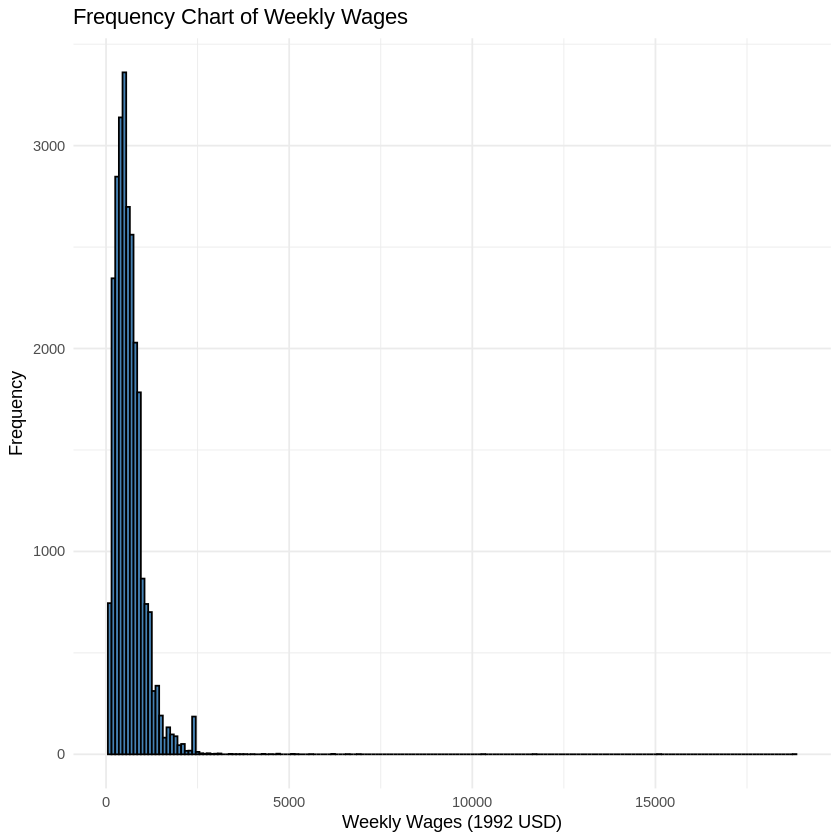

In [ ]:
install.packages('ggplot2')
library(ggplot2)

ggplot(ex1029, aes(x = WeeklyEarnings)) +
  geom_histogram(binwidth = 100, fill = 'steelblue', color = 'black') + # Adjust binwidth as needed
  labs(title = "Frequency Chart of Weekly Wages",
       x = "Weekly Wages (1992 USD)",
       y = "Frequency") +
  theme_minimal()

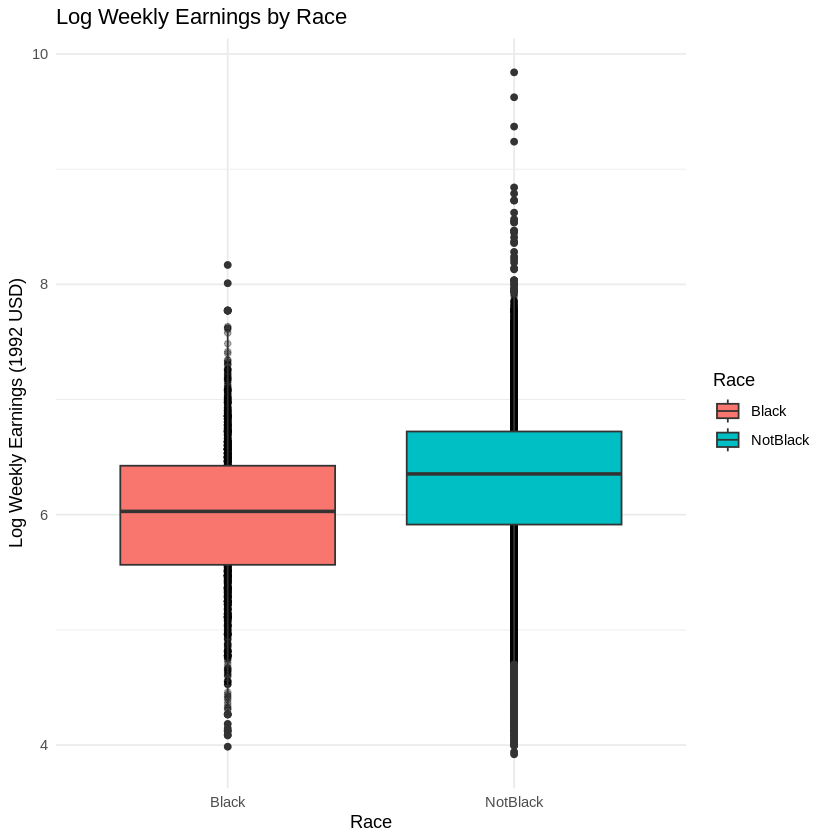

In [ ]:
ggplot(ex1029, aes(x = Race, y = log(WeeklyEarnings), fill = Race)) + geom_point(alpha = 0.3) +
  geom_boxplot() +
  labs(title = "Log Weekly Earnings by Race",
       x = "Race",
       y = "Log Weekly Earnings (1992 USD)",
       fill = "Race") +
  theme_minimal()

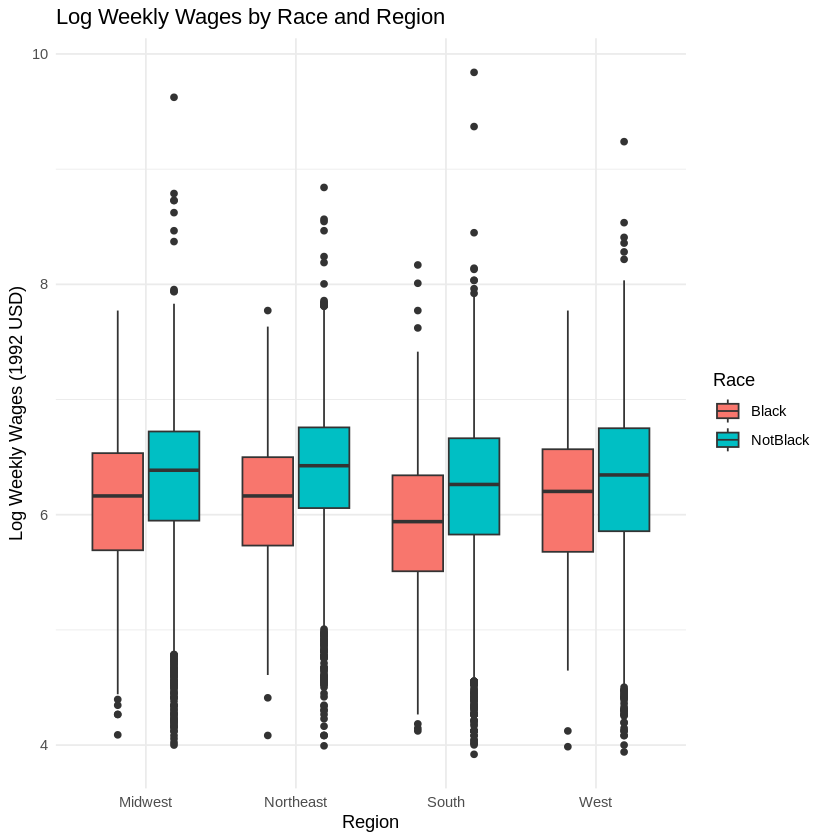

In [ ]:
# Create a box plot of wages by race within regions
ggplot(ex1029, aes(x = Region, y = log(WeeklyEarnings), fill = Race)) +
  geom_boxplot() +
  labs(title = "Log Weekly Wages by Race and Region",
       x = "Region",
       y = "Log Weekly Wages (1992 USD)",
       fill = "Race") +
  theme_minimal()

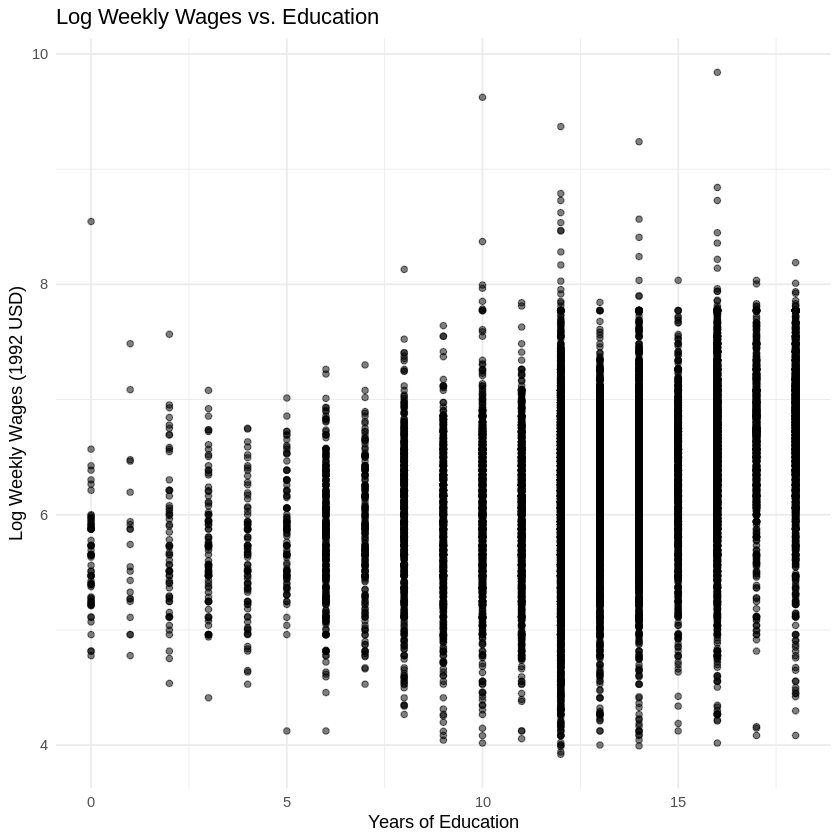

In [ ]:
# Create a scatterplot of Wages vs. Education
ggplot(ex1029, aes(x = Educ, y = log(WeeklyEarnings))) +
  geom_point(alpha = 0.5) + # Use geom_point for scatterplot, alpha for overplotting
  labs(title = "Log Weekly Wages vs. Education",
       x = "Years of Education",
       y = "Log Weekly Wages (1992 USD)") +
  theme_minimal()

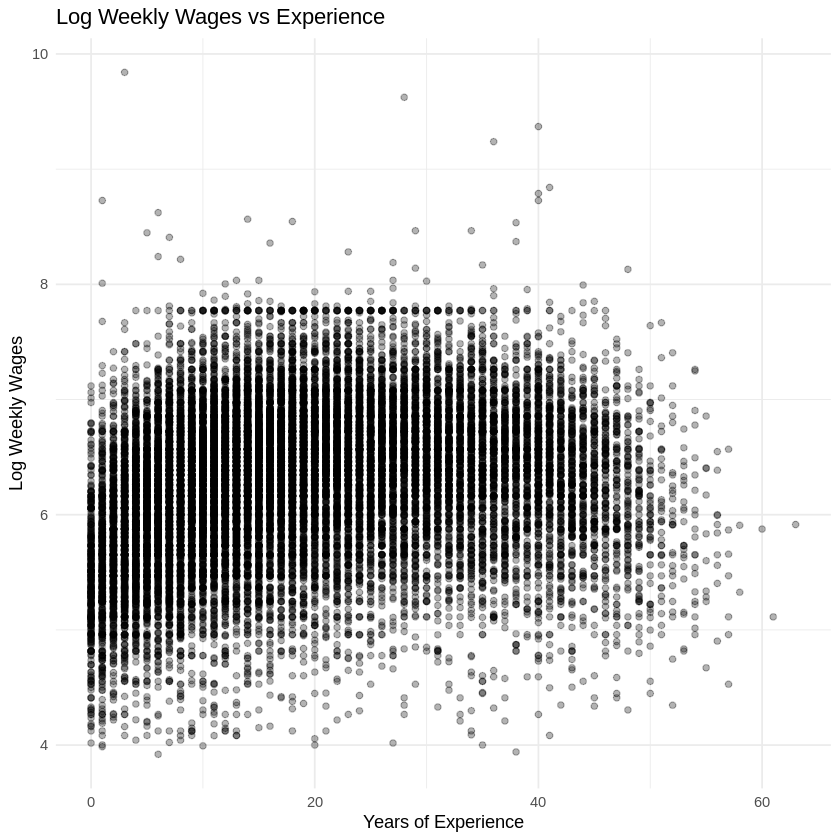

In [ ]:
ggplot(ex1029, aes(x = Exper, y = log(WeeklyEarnings))) +
  geom_point(alpha = 0.3) +
  labs(title = "Log Weekly Wages vs Experience",
       x = "Years of Experience",
       y = "Log Weekly Wages") +
  theme_minimal()

Initial graphical analysis shows that wages are right-skewed, so a log transformation was used. Boxplots suggest that Black males generally earn less than non-Black males, and if this difference varies across regions, it is minimal. Scatterplots indicate positive relationships between wages and both education and experience, supporting their inclusion in the model.

In [ ]:
#here is the first model

model1 <- lm(log(WeeklyEarnings) ~ Race + Educ + Exper + Region + Race:Region, data = ex1029)

In [ ]:
summary(model1)


Call:
lm(formula = log(WeeklyEarnings) ~ Race + Educ + Exper + Region + 
    Race:Region, data = ex1029)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.6642 -0.3005  0.0436  0.3483  3.5838 

Coefficients:
                               Estimate Std. Error t value Pr(>|t|)    
(Intercept)                   4.4767403  0.0345155 129.702  < 2e-16 ***
RaceNotBlack                  0.1952246  0.0306104   6.378 1.83e-10 ***
Educ                          0.0990514  0.0012024  82.376  < 2e-16 ***
Exper                         0.0177459  0.0002822  62.887  < 2e-16 ***
RegionNortheast               0.0584417  0.0419131   1.394  0.16322    
RegionSouth                  -0.0950662  0.0336683  -2.824  0.00475 ** 
RegionWest                    0.0394811  0.0502137   0.786  0.43172    
RaceNotBlack:RegionNortheast  0.0036502  0.0430833   0.085  0.93248    
RaceNotBlack:RegionSouth      0.0416548  0.0349826   1.191  0.23377    
RaceNotBlack:RegionWest      -0.0368004  0.0512287  -0.718  0.472

An interaction between race and region was initially included to allow the race effect to differ by region, as suggested by the problem statement. Because the interaction terms were not statistically significant, a simpler additive model was also considered. The final model suggests that, after controlling for education, experience, and region, Black males were paid less on average than non-Black males, with little evidence that this difference varied substantially by region.

In [ ]:
model <- lm(log(WeeklyEarnings) ~ Race + Educ + Exper + Region, data = ex1029)
summary(model)


Call:
lm(formula = log(WeeklyEarnings) ~ Race + Educ + Exper + Region, 
    data = ex1029)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.6653 -0.3013  0.0432  0.3488  3.5868 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)      4.4567340  0.0221825 200.912  < 2e-16 ***
RaceNotBlack     0.2156000  0.0126999  16.977  < 2e-16 ***
Educ             0.0990952  0.0012020  82.443  < 2e-16 ***
Exper            0.0177516  0.0002822  62.914  < 2e-16 ***
RegionNortheast  0.0619622  0.0097088   6.382 1.78e-10 ***
RegionSouth     -0.0575524  0.0091288  -6.304 2.94e-10 ***
RegionWest       0.0034676  0.0099176   0.350    0.727    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.533 on 25430 degrees of freedom
Multiple R-squared:  0.2707,	Adjusted R-squared:  0.2705 
F-statistic:  1573 on 6 and 25430 DF,  p-value: < 2.2e-16


This is much better. I am going to run an ANOVA to check which model is better. For this simplified model, RegionWest is not significant but the other two region variables are, so I will leave that in there.

In [ ]:
anova(model, model1)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,25430,7224.493,NA,NA,NA,NA
2,25427,7223.283,3,1.210058,1.419859,0.234791


We fail to reject the null hypothesis with a p-value of 0.234. This means the reduced model is efficient. We will continue with the model without interaction terms.

#Assumptions
##Independence
Independence assumes that each individual’s wage is unrelated to others in the dataset. Given that the data come from a large survey of individuals, this assumption is reasonably satisfied, although it cannot be fully confirmed with observational data.

##Linearity & Variance

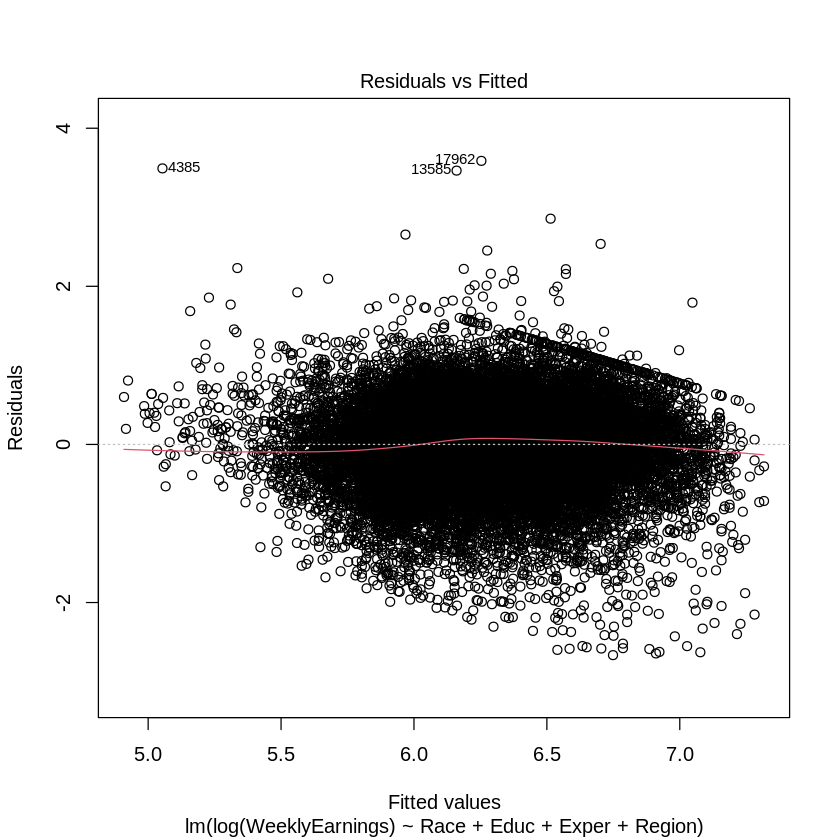

In [ ]:
plot(model, which = 1)

In [ ]:
install.packages('lawstat')
library(lawstat)

levene.test(residuals(model), group = interaction(model$model$Race, model$model$Region))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




	Modified robust Brown-Forsythe Levene-type test based on the absolute
	deviations from the median

data:  residuals(model)
Test Statistic = 6.0643, p-value = 4.319e-07


The assumption of constant variance was assessed using the residuals versus fitted plot and a Levene test. Although the formal test suggested non-constant variance, this is not surprising with such a large sample size. The residual plot did not show severe heteroscedasticity, so the violation does not appear serious enough to invalidate the model.

As for linearity, residual plots show no strong patterns, suggesting that the assumption of linearity is reasonably satisfied.

##Normality

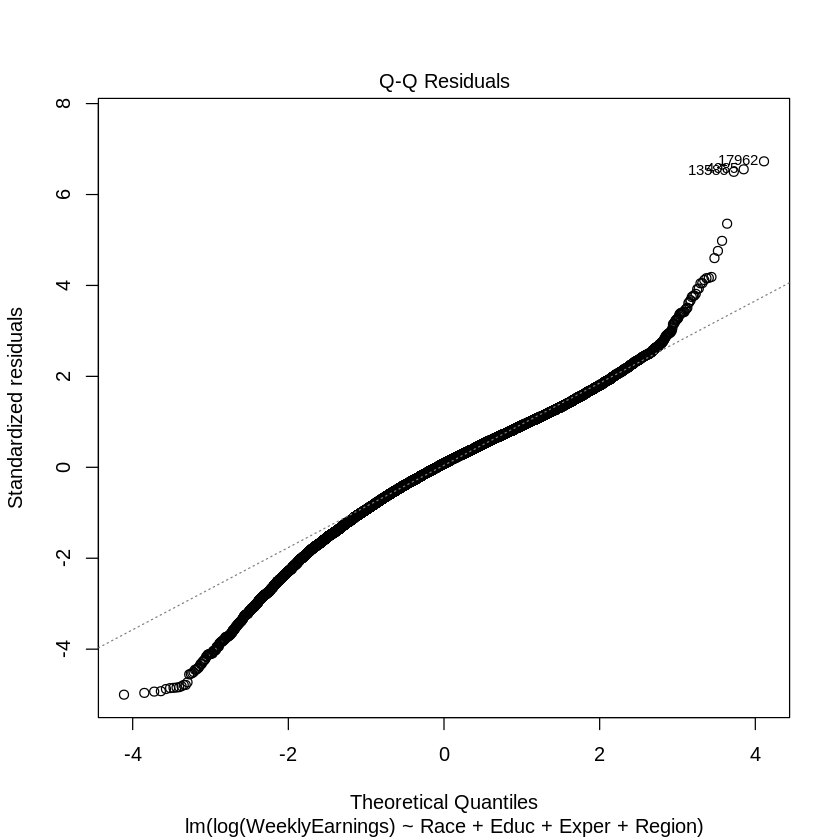

In [ ]:
plot(model, which = 2)

Normality of the residuals was assessed using a Q-Q plot. The plot shows that the residuals generally follow a straight line through the middle, with some deviation in the tails. These deviations suggest that the residuals are not perfectly normally distributed, particularly at extreme values. However, given the large sample size, such deviations are not unexpected and do not substantially affect the validity of the regression model. Overall, the normality assumption appears to be reasonably satisfied.

#Statistical Conclusions

In [ ]:
exp(coef(model))

(Intercept)    RaceNotBlack            Educ           Exper RegionNortheast 
     86.2055020       1.2406061       1.1041715       1.0179101       1.0639221 
    RegionSouth      RegionWest 
      0.9440724       1.0034737

In [ ]:
exp(confint(model))

,2.5 %,97.5 %
(Intercept),82.5376873,90.0363073
RaceNotBlack,1.2101055,1.2718754
Educ,1.1015731,1.1067759
Exper,1.0173473,1.0184732
RegionNortheast,1.0438673,1.0843622
RegionSouth,0.9273304,0.9611167
RegionWest,0.9841555,1.0231710


A multiple linear regression model was used to examine the relationship between wages and race while controlling for education, experience, and region. Because the problem suggested that the wage difference by race might depend on region, an interaction between race and region was initially included. However, the interaction terms were not statistically significant, so the evidence does not suggest that the racial wage gap varies substantially by region. A simpler additive model was then used for interpretation.

In the final model, race remained a statistically significant predictor of log weekly wages after controlling for education, experience, and region. The exponentiated coefficient for race indicates that non-Black males earned more on average than Black males with the same education, experience, and region. Specifically, the confidence interval for this effect is approximately (1.21, 1.27), indicating that non-Black males earn between 21% and 27% more than comparable Black males.

Education and experience were also positively associated with wages. The exponentiated confidence interval for education, approximately (1.102, 1.107), suggests that each additional year of education is associated with about a 10.2% to 10.7% increase in wages, holding other variables constant. Similarly, experience has a smaller positive effect on wages.

Regional differences were also observed. The confidence intervals for the Northeast and South do not contain 1, indicating meaningful differences relative to the baseline region, while the interval for the West includes 1, suggesting no statistically significant difference for that region.

Although the adjusted $R^2$ is approximately 27%, indicating that the model explains a moderate portion of the variability in wages, this is not unexpected given the complexity of wage determination. Overall, the results provide convincing evidence of an association between race and wages, with Black males earning less on average than comparable non-Black males in this dataset.

#All confidence intervals:

Intercept: (82.537, 90.036)

RaceNotBlack: (1.2101055	1.2718754)

Education: (1.102, 1.107)

Experience: (1.017, 1.018)

RegionNE: (1.044, 1.085)

RegionS: (0.927, 0.961)

RegionW: (0.984, 1.023)

#Scope of Inference
The data come from an observational survey of full-time employed males in the United States, so the conclusions apply to similar full-time working males represented by this population and time period. Because this was not a randomized experiment, the analysis can identify associations between race and wages but cannot establish causation. Although the sample size is large and the statistical evidence may be strong, other variables not included in the model, such as occupation or industry, may also help explain wage differences. Therefore, the results are convincing as evidence of an association, but not as proof of a causal effect of race on wages.